# Strict Neural Spatial AOG Diagnostics

This notebook diagnoses the strict Song-Chun-style Spatial AOG path that combines Stage-1 part segmentation terminals with an explicit And-Or grammar and parse-graph scoring.

It saves all figures, tables, and a compact report to `OUT_DIR`. The diagnostics are intentionally focused on **intermediate evidence** rather than only final accuracy:

- cached Stage-1 terminal coverage and repeated-part components
- grammar integrity: class Or-nodes, template And-nodes, slots, and horizontal relation factors
- parser logits, uniform-collapse checks, template usage, and class confusion
- node/edge/template score decomposition
- parse graph visualizations: terminal proposals, assigned slots, missing slots, and relation edges
- relation residual diagnostics for predicted parse graphs

The notebook expects the strict AOG overlay to be copied into the repo root, with modules under `src/partcat_hkg/strict_aog/`.


## 0. User settings

Edit these paths before running. The defaults match the commands from the strict AOG implementation bundle.


In [1]:
from pathlib import Path
import os, sys, json, math, random, time

REPO_ROOT = Path.cwd()
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Main inputs.
CONFIG_PATH = REPO_ROOT / "configs/stage1_quality_upgrade.yaml"          # optional, only needed for raw-image overlays
GRAMMAR_PATH = REPO_ROOT / "runs/strict_aog_cache/strict_aog.pt"
CACHE_PATH = REPO_ROOT / "runs/strict_aog_cache/val_strict_aog_terminals.pt"
CKPT_PATH = REPO_ROOT / "runs/strict_aog/checkpoints/strict_aog_best.pt"   # optional; leave as non-existing path for untrained grammar parser

# Outputs.
OUT_DIR = REPO_ROOT / "runs/strict_aog_diagnostics"
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"
REPORT_DIR = OUT_DIR / "reports"
for d in (OUT_DIR, FIG_DIR, TAB_DIR, REPORT_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Evaluation/visualization knobs.
DEVICE = "cuda" if __import__('torch').cuda.is_available() else "cpu"
BATCH_SIZE = 64
MAX_EVAL_BATCHES = 50      # set 0 for all batches
NUM_VIS_SAMPLES = 12
RANDOM_SEED = 123
ASSIGNMENT = "max"         # "max" is easiest for readable parse overlays; use "sinkhorn" for trained parser behavior
ENABLE_EDGES = True
USE_RAW_IMAGE_DATASET = False  # set True to overlay terminals on original images using CONFIG_PATH + PartImageNet paths

print("REPO_ROOT:", REPO_ROOT)
print("DEVICE:", DEVICE)
print("OUT_DIR:", OUT_DIR)


REPO_ROOT: /home/dfli/instance_slot_aog
DEVICE: cuda
OUT_DIR: /home/dfli/instance_slot_aog/runs/strict_aog_diagnostics


## 1. Imports and project objects


In [2]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from partcat_hkg.strict_aog.grammar import load_strict_aog, GEOM_FEATURE_NAMES, REL_FEATURE_NAMES
from partcat_hkg.strict_aog.data import StrictAOGTerminalDataset, collate_strict_aog
from partcat_hkg.strict_aog.parser import StrictAOGParser, ParserConfig, strict_aog_loss
from partcat_hkg.strict_aog.terminals import terminal_pair_relations

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

manifest = []

def savefig(path: Path, fig=None, dpi=180):
    path.parent.mkdir(parents=True, exist_ok=True)
    if fig is None:
        fig = plt.gcf()
    fig.tight_layout()
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    manifest.append({"kind": "figure", "path": str(path.relative_to(OUT_DIR)), "bytes": path.stat().st_size})
    return path

def save_table(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    manifest.append({"kind": "table", "path": str(path.relative_to(OUT_DIR)), "rows": int(len(df)), "cols": int(len(df.columns))})
    return path

def save_json(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(obj, indent=2, default=lambda x: float(x) if hasattr(x, "__float__") else str(x)), encoding="utf-8")
    manifest.append({"kind": "json", "path": str(path.relative_to(OUT_DIR)), "bytes": path.stat().st_size})
    return path

print("Imports OK")


Imports OK


## 2. Load grammar, cache, and optional parser checkpoint

This cell also runs the first set of hard sanity checks: schema/class count, terminal tensor keys, and valid template/slot counts.


In [3]:
assert GRAMMAR_PATH.exists(), f"Missing grammar: {GRAMMAR_PATH}"
assert CACHE_PATH.exists(), f"Missing terminal cache: {CACHE_PATH}"

grammar = load_strict_aog(str(GRAMMAR_PATH), map_location="cpu")
dataset = StrictAOGTerminalDataset(CACHE_PATH, map_location="cpu")
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_strict_aog, num_workers=0)

pcfg = ParserConfig(
    assignment=ASSIGNMENT,
    assignment_tau=0.35,
    sinkhorn_iters=16,
    class_chunk=0,
)
parser = StrictAOGParser(grammar, pcfg).to(DEVICE)

ckpt_loaded = False
if CKPT_PATH.exists():
    ckpt = torch.load(CKPT_PATH, map_location="cpu")
    state = ckpt.get("model", ckpt) if isinstance(ckpt, dict) else ckpt
    missing, unexpected = parser.load_state_dict(state, strict=False)
    ckpt_loaded = True
    print(f"Loaded parser checkpoint: {CKPT_PATH}")
    print("missing keys:", missing)
    print("unexpected keys:", unexpected)
else:
    print("No parser checkpoint loaded; using grammar statistics + default calibration only.")

sample0 = dataset[0]
print("records:", len(dataset))
print("classes:", grammar.num_classes, "templates/class:", grammar.num_templates, "max_slots:", grammar.max_slots)
print("token_dim:", grammar.token_dim)
print("edges:", int(grammar.edges.shape[0]))
print("valid templates:", int(grammar.template_valid.sum().item()))
print("valid slots:", int(grammar.slot_valid.sum().item()))
print("cache keys:", sorted(sample0.keys()))
print({k: tuple(v.shape) if torch.is_tensor(v) else type(v).__name__ for k, v in sample0.items()})

summary = {
    "grammar_path": str(GRAMMAR_PATH),
    "cache_path": str(CACHE_PATH),
    "checkpoint_path": str(CKPT_PATH) if ckpt_loaded else "",
    "num_records": len(dataset),
    "num_classes": int(grammar.num_classes),
    "num_templates": int(grammar.num_templates),
    "max_slots": int(grammar.max_slots),
    "token_dim": int(grammar.token_dim),
    "num_edges": int(grammar.edges.shape[0]),
    "valid_templates": int(grammar.template_valid.sum().item()),
    "valid_slots": int(grammar.slot_valid.sum().item()),
}
save_json(summary, REPORT_DIR / "00_load_summary.json")
summary


Loaded parser checkpoint: /home/dfli/instance_slot_aog/runs/strict_aog/checkpoints/strict_aog_best.pt
missing keys: []
unexpected keys: []
records: 1205
classes: 11 templates/class: 3 max_slots: 12
token_dim: 128
edges: 287
valid templates: 33
valid slots: 241
cache keys: ['obj_label', 'terminal_geom', 'terminal_mask', 'terminal_part', 'terminal_score', 'terminal_token', 'terminal_valid']
{'terminal_valid': (32,), 'terminal_part': (32,), 'terminal_score': (32,), 'terminal_geom': (32, 6), 'terminal_token': (32, 128), 'terminal_mask': (32, 64, 64), 'obj_label': ()}


{'grammar_path': '/home/dfli/instance_slot_aog/runs/strict_aog_cache/strict_aog.pt',
 'cache_path': '/home/dfli/instance_slot_aog/runs/strict_aog_cache/val_strict_aog_terminals.pt',
 'checkpoint_path': '/home/dfli/instance_slot_aog/runs/strict_aog/checkpoints/strict_aog_best.pt',
 'num_records': 1205,
 'num_classes': 11,
 'num_templates': 3,
 'max_slots': 12,
 'token_dim': 128,
 'num_edges': 287,
 'valid_templates': 33,
 'valid_slots': 241}

## 3. Terminal cache audit

This checks whether Stage-1 terminal extraction is healthy. A strict AOG parser cannot work if the terminal cache has too few valid terminals, invalid part IDs, NaNs, or a severe class/part coverage mismatch.


In [4]:
rows = []
part_counts = torch.zeros(grammar.num_classes, len(grammar.part_names), dtype=torch.long)
terminal_score_by_part = {k: [] for k in range(len(grammar.part_names))}

for idx in range(len(dataset)):
    r = dataset[idx]
    valid = r["terminal_valid"].bool()
    parts = r["terminal_part"].long()
    scores = r["terminal_score"].float()
    geoms = r["terminal_geom"].float()
    label = int(r["obj_label"].item())
    n_valid = int(valid.sum().item())
    bad_part = int(((parts[valid] < 0) | (parts[valid] >= len(grammar.part_names))).sum().item()) if n_valid else 0
    finite = True
    for k, v in r.items():
        if torch.is_tensor(v) and v.dtype.is_floating_point:
            finite = finite and bool(torch.isfinite(v).all().item())
    rows.append({
        "index": idx,
        "label": label,
        "class_name": grammar.class_names[label] if 0 <= label < len(grammar.class_names) else str(label),
        "n_terminals": n_valid,
        "mean_score": float(scores[valid].mean().item()) if n_valid else 0.0,
        "max_score": float(scores[valid].max().item()) if n_valid else 0.0,
        "mean_area": float(geoms[valid, 4].mean().item()) if n_valid else 0.0,
        "bad_part_ids": bad_part,
        "all_finite": finite,
    })
    for p in parts[valid].tolist():
        if 0 <= int(p) < len(grammar.part_names) and 0 <= label < grammar.num_classes:
            part_counts[label, int(p)] += 1
            terminal_score_by_part[int(p)].extend(scores[valid & (parts == int(p))].tolist())

terminal_df = pd.DataFrame(rows)
save_table(terminal_df, TAB_DIR / "terminal_cache_per_image.csv")

part_rows = []
for p, name in enumerate(grammar.part_names):
    vals = terminal_score_by_part[p]
    part_rows.append({
        "part_id": p,
        "part_name": name,
        "n_terminals": int(part_counts[:, p].sum().item()),
        "classes_with_part": int((part_counts[:, p] > 0).sum().item()),
        "mean_score": float(np.mean(vals)) if vals else 0.0,
        "median_score": float(np.median(vals)) if vals else 0.0,
    })
part_df = pd.DataFrame(part_rows).sort_values("n_terminals", ascending=False)
save_table(part_df, TAB_DIR / "terminal_cache_per_part.csv")

class_rows = []
for c, name in enumerate(grammar.class_names):
    mask = terminal_df["label"] == c
    class_rows.append({
        "class_id": c,
        "class_name": name,
        "n_images": int(mask.sum()),
        "mean_terminals": float(terminal_df.loc[mask, "n_terminals"].mean()) if mask.any() else 0.0,
        "zero_terminal_images": int((terminal_df.loc[mask, "n_terminals"] == 0).sum()) if mask.any() else 0,
        "total_terminals": int(part_counts[c].sum().item()),
    })
class_df = pd.DataFrame(class_rows).sort_values("n_images", ascending=False)
save_table(class_df, TAB_DIR / "terminal_cache_per_class.csv")

print(terminal_df.describe(include="all"))
print("zero-terminal images:", int((terminal_df.n_terminals == 0).sum()))
print("non-finite records:", int((~terminal_df.all_finite).sum()))
print("bad part id records:", int((terminal_df.bad_part_ids > 0).sum()))
part_df.head(20)


              index        label class_name  n_terminals   mean_score    max_score    mean_area  bad_part_ids all_finite
count   1205.000000  1205.000000       1205  1205.000000  1205.000000  1205.000000  1205.000000        1205.0       1205
unique          NaN          NaN         11          NaN          NaN          NaN          NaN           NaN          1
top             NaN          NaN  quadruped          NaN          NaN          NaN          NaN           NaN       True
freq            NaN          NaN        352          NaN          NaN          NaN          NaN           NaN       1205
mean     602.000000     6.582573        NaN     5.252282     0.792134     0.947463     0.078465           0.0        NaN
std      347.997845     2.815334        NaN     2.298943     0.099504     0.028885     0.077359           0.0        NaN
min        0.000000     0.000000        NaN     1.000000     0.521174     0.595693     0.001094           0.0        NaN
25%      301.000000     4.000000

,part_id,part_name,n_terminals,classes_with_part,mean_score,median_score
0,0,body,1959,11,0.704750,0.709676
5,5,head,1430,11,0.767407,0.849912
3,3,foot,1305,9,0.685515,0.711993
10,10,tail,546,9,0.704388,0.718599
11,11,wheel,309,6,0.857590,0.930038
4,4,hand,236,3,0.639093,0.638586
2,2,fin,193,4,0.726127,0.780720
6,6,mirror,121,2,0.779183,0.814727
12,12,wing,107,6,0.673562,0.645666
8,8,sail,41,3,0.713831,0.718217


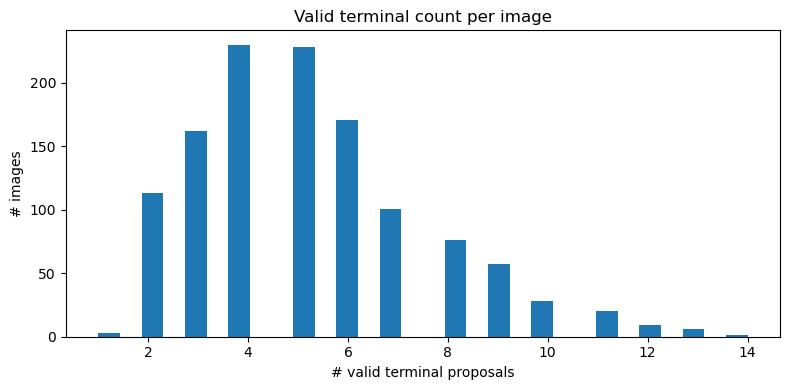

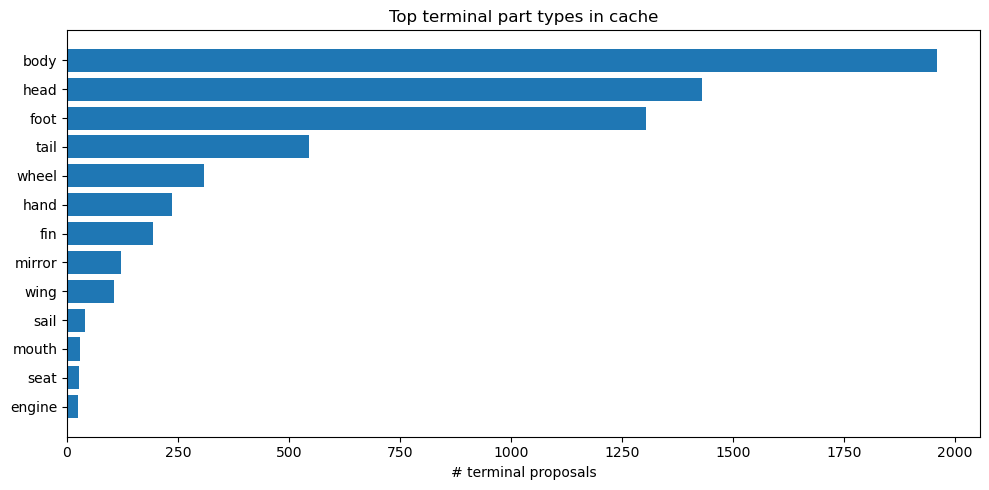

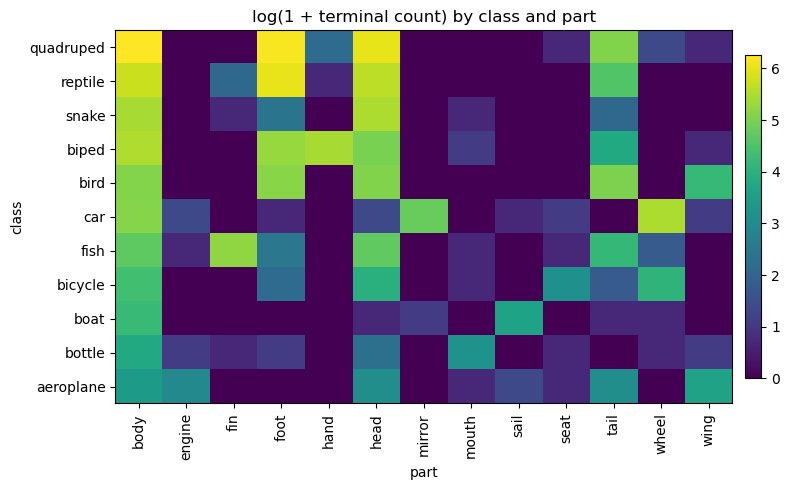

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(terminal_df["n_terminals"].values, bins=30)
ax.set_title("Valid terminal count per image")
ax.set_xlabel("# valid terminal proposals")
ax.set_ylabel("# images")
savefig(FIG_DIR / "terminal_count_histogram.png", fig)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
top = part_df.head(30).iloc[::-1]
ax.barh(top["part_name"], top["n_terminals"])
ax.set_title("Top terminal part types in cache")
ax.set_xlabel("# terminal proposals")
savefig(FIG_DIR / "top_terminal_parts.png", fig)
plt.show()

# Class x part heatmap for top classes by images.
top_classes = class_df.head(min(40, len(class_df)))["class_id"].tolist()
heat = part_counts[top_classes].numpy()
fig, ax = plt.subplots(figsize=(max(8, len(grammar.part_names) * 0.45), max(5, len(top_classes) * 0.22)))
im = ax.imshow(np.log1p(heat), aspect="auto")
ax.set_title("log(1 + terminal count) by class and part")
ax.set_xlabel("part")
ax.set_ylabel("class")
ax.set_xticks(range(len(grammar.part_names)))
ax.set_xticklabels(grammar.part_names, rotation=90)
ax.set_yticks(range(len(top_classes)))
ax.set_yticklabels([grammar.class_names[c] for c in top_classes])
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
savefig(FIG_DIR / "class_part_terminal_heatmap.png", fig)
plt.show()


## 4. Grammar integrity audit

This maps the grammar back to the AOG structure:

- class root Or-node: `class_prior`
- template And-node branch: `template_prior`, `template_valid`
- child slots: `slot_valid`, `slot_part`, `slot_required`, `slot_presence`
- horizontal relation factors: `edges`, `edge_rel_mean`, `edge_rel_var`, `edge_support`


In [6]:
# Per-class/template summary.
g_rows = []
edge_counts = torch.zeros(grammar.num_classes, grammar.num_templates, dtype=torch.long)
for e in grammar.edges.tolist():
    c, a, si, sj = map(int, e)
    if 0 <= c < grammar.num_classes and 0 <= a < grammar.num_templates:
        edge_counts[c, a] += 1

for c in range(grammar.num_classes):
    for a in range(grammar.num_templates):
        sv = grammar.slot_valid[c, a].bool()
        sp = grammar.slot_part[c, a]
        g_rows.append({
            "class_id": c,
            "class_name": grammar.class_names[c],
            "template": a,
            "template_valid": float(grammar.template_valid[c, a].item()),
            "template_prior": float(grammar.template_prior[c, a].item()),
            "n_slots": int(sv.sum().item()),
            "n_required_slots": int((grammar.slot_required[c, a].bool() & sv).sum().item()),
            "n_edges": int(edge_counts[c, a].item()),
            "slot_parts": ",".join([grammar.part_names[int(x)] for x in sp[sv].tolist() if int(x) >= 0]),
        })
grammar_df = pd.DataFrame(g_rows)
save_table(grammar_df, TAB_DIR / "grammar_class_template_summary.csv")

edge_rows = []
for e, row in enumerate(grammar.edges.tolist()):
    c, a, si, sj = map(int, row)
    pi = int(grammar.slot_part[c, a, si].item()) if c < grammar.num_classes and a < grammar.num_templates else -1
    pj = int(grammar.slot_part[c, a, sj].item()) if c < grammar.num_classes and a < grammar.num_templates else -1
    edge_rows.append({
        "edge_id": e,
        "class_id": c,
        "class_name": grammar.class_names[c] if 0 <= c < len(grammar.class_names) else str(c),
        "template": a,
        "slot_i": si,
        "slot_j": sj,
        "part_i": grammar.part_names[pi] if 0 <= pi < len(grammar.part_names) else str(pi),
        "part_j": grammar.part_names[pj] if 0 <= pj < len(grammar.part_names) else str(pj),
        "edge_type": int(grammar.edge_type[e].item()) if grammar.edge_type.numel() else -1,
        "support": float(grammar.edge_support[e].item()) if grammar.edge_support.numel() else 0.0,
        "mean_rel_norm": float(grammar.edge_rel_mean[e].norm().item()) if grammar.edge_rel_mean.numel() else 0.0,
        "mean_var": float(grammar.edge_rel_var[e].mean().item()) if grammar.edge_rel_var.numel() else 0.0,
    })
edge_df = pd.DataFrame(edge_rows)
save_table(edge_df, TAB_DIR / "grammar_edges.csv")

# Warnings.
warnings = []
if int(grammar.template_valid.sum().item()) == 0:
    warnings.append("No valid templates in grammar.")
if int(grammar.slot_valid.sum().item()) == 0:
    warnings.append("No valid slots in grammar.")
no_template_classes = grammar_df.groupby("class_id")["template_valid"].sum()
for c, v in no_template_classes.items():
    if v <= 0:
        warnings.append(f"Class {c} {grammar.class_names[c]} has no valid templates.")
no_slot_templates = grammar_df[(grammar_df.template_valid > 0) & (grammar_df.n_slots == 0)]
if len(no_slot_templates):
    warnings.append(f"{len(no_slot_templates)} valid templates have zero slots.")
if len(edge_df) == 0:
    warnings.append("Grammar has zero horizontal relation edges.")

save_json({"warnings": warnings}, REPORT_DIR / "01_grammar_warnings.json")
print("warnings:", warnings or "none")
grammar_df.head(20)


warnings: none


,class_id,class_name,template,template_valid,template_prior,n_slots,n_required_slots,n_edges,slot_parts
0,0,aeroplane,0,1.0,0.367041,8,3,10,"body,body,body,engine,engine,engine,head,head"
1,0,aeroplane,1,1.0,0.329588,7,3,7,"body,body,body,engine,engine,head,head"
2,0,aeroplane,2,1.0,0.303371,10,6,12,"body,body,body,body,engine,engine,engine,engin..."
3,1,bicycle,0,1.0,0.399632,7,6,12,"body,body,body,body,head,head,head"
4,1,bicycle,1,1.0,0.351750,4,4,3,"body,body,head,seat"
5,1,bicycle,2,1.0,0.248619,9,5,12,"body,body,body,head,head,head,head,seat,seat"
6,2,biped,0,1.0,0.387698,9,5,12,"body,foot,foot,foot,hand,hand,hand,head,head"
7,2,biped,1,1.0,0.320130,12,7,12,"body,body,body,body,foot,foot,foot,foot,hand,h..."
8,2,biped,2,1.0,0.292171,9,4,12,"body,body,body,body,hand,hand,hand,head,head"
9,3,bird,0,1.0,0.441265,6,4,6,"body,body,foot,head,head,tail"


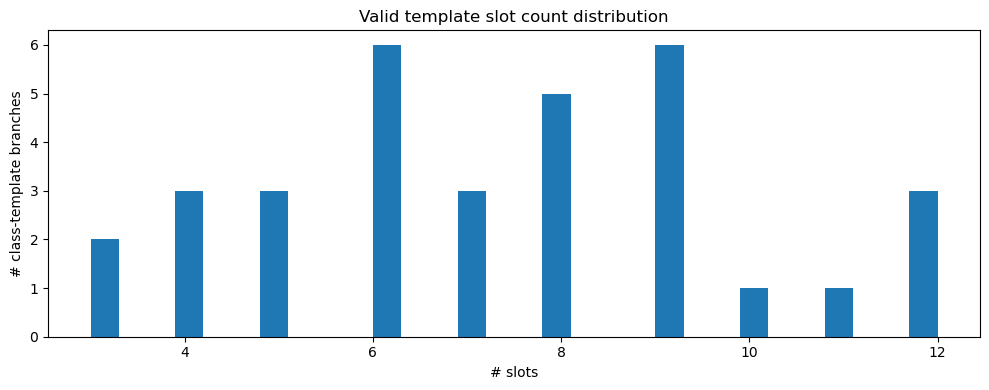

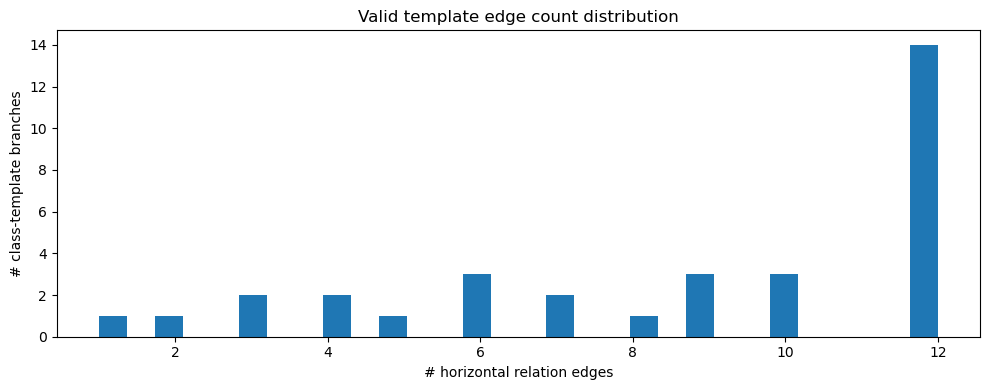

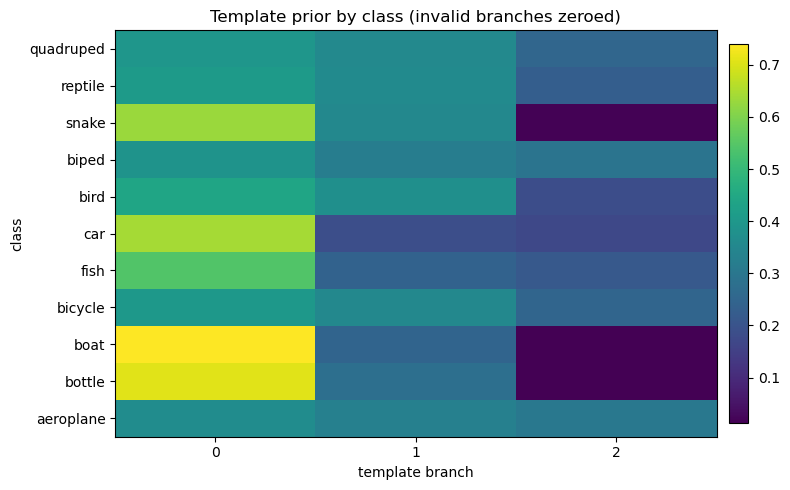

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(grammar_df.loc[grammar_df.template_valid > 0, "n_slots"], bins=30)
ax.set_title("Valid template slot count distribution")
ax.set_xlabel("# slots")
ax.set_ylabel("# class-template branches")
savefig(FIG_DIR / "grammar_slot_count_histogram.png", fig)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(grammar_df.loc[grammar_df.template_valid > 0, "n_edges"], bins=30)
ax.set_title("Valid template edge count distribution")
ax.set_xlabel("# horizontal relation edges")
ax.set_ylabel("# class-template branches")
savefig(FIG_DIR / "grammar_edge_count_histogram.png", fig)
plt.show()

# Template validity/prior heatmap for top classes.
top_classes_for_grammar = class_df.head(min(50, len(class_df)))["class_id"].tolist()
prior_heat = grammar.template_prior[top_classes_for_grammar].numpy() * grammar.template_valid[top_classes_for_grammar].numpy()
fig, ax = plt.subplots(figsize=(8, max(5, len(top_classes_for_grammar) * 0.20)))
im = ax.imshow(prior_heat, aspect="auto")
ax.set_title("Template prior by class (invalid branches zeroed)")
ax.set_xlabel("template branch")
ax.set_ylabel("class")
ax.set_xticks(range(grammar.num_templates))
ax.set_yticks(range(len(top_classes_for_grammar)))
ax.set_yticklabels([grammar.class_names[c] for c in top_classes_for_grammar])
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
savefig(FIG_DIR / "template_prior_heatmap.png", fig)
plt.show()


## 5. Parser evaluation and uniform-collapse diagnostics

This section evaluates the parser on cached terminal tensors. It saves per-sample predictions and flags the failure mode you saw earlier: final/HKG/base all at chance with nearly constant logits.


In [8]:
@torch.no_grad()
def evaluate_parser(max_batches=MAX_EVAL_BATCHES, enable_edges=ENABLE_EDGES):
    parser.eval()
    pred_rows = []
    idx0 = 0
    total = correct = 0
    for bi, batch in enumerate(loader):
        if max_batches and bi >= max_batches:
            break
        labels = batch["obj_label"].to(DEVICE)
        out = parser(batch, enable_edges=enable_edges, return_parse=False)
        logits = out["logits"].detach().cpu()
        probs = torch.softmax(logits, dim=-1)
        pred = logits.argmax(-1)
        topv, topi = torch.topk(logits, k=min(5, logits.shape[-1]), dim=-1)
        for b in range(logits.shape[0]):
            y = int(labels[b].detach().cpu().item())
            p = int(pred[b].item())
            row = {
                "index": idx0 + b,
                "true": y,
                "true_name": grammar.class_names[y] if 0 <= y < len(grammar.class_names) else str(y),
                "pred": p,
                "pred_name": grammar.class_names[p] if 0 <= p < len(grammar.class_names) else str(p),
                "correct": int(p == y),
                "logit_std": float(logits[b].std().item()),
                "logit_entropy": float(-(probs[b] * torch.log(probs[b].clamp_min(1e-8))).sum().item()),
                "top1_logit": float(topv[b, 0].item()),
                "top2_margin": float((topv[b, 0] - topv[b, 1]).item()) if topv.shape[1] > 1 else 0.0,
                "n_terminals": int(batch["terminal_valid"][b].sum().item()),
                "best_template_pred": int(out["best_template"][b, p].detach().cpu().item()),
                "best_template_true": int(out["best_template"][b, y].detach().cpu().item()) if 0 <= y < out["best_template"].shape[1] else -1,
            }
            for k in range(topi.shape[1]):
                row[f"top{k+1}_class"] = int(topi[b, k].item())
                row[f"top{k+1}_name"] = grammar.class_names[int(topi[b, k].item())]
                row[f"top{k+1}_logit"] = float(topv[b, k].item())
            pred_rows.append(row)
        total += int(labels.numel())
        correct += int((pred.to(labels.cpu()) == labels.cpu()).sum().item())
        idx0 += logits.shape[0]
    df = pd.DataFrame(pred_rows)
    acc = float(df["correct"].mean()) if len(df) else 0.0
    summary = {
        "n_eval": int(len(df)),
        "accuracy": acc,
        "mean_logit_std": float(df["logit_std"].mean()) if len(df) else 0.0,
        "median_logit_std": float(df["logit_std"].median()) if len(df) else 0.0,
        "mean_entropy": float(df["logit_entropy"].mean()) if len(df) else 0.0,
        "chance_entropy_lnC": float(math.log(max(grammar.num_classes, 1))),
        "pred_unique_classes": int(df["pred"].nunique()) if len(df) else 0,
    }
    summary["uniform_warning"] = bool(summary["mean_logit_std"] < 1e-4 or summary["pred_unique_classes"] <= 1)
    return df, summary

pred_df, eval_summary = evaluate_parser()
save_table(pred_df, TAB_DIR / "parser_predictions.csv")
save_json(eval_summary, REPORT_DIR / "02_eval_summary.json")
print(json.dumps(eval_summary, indent=2))
pred_df.head(10)


{
  "n_eval": 1205,
  "accuracy": 0.9510373443983402,
  "mean_logit_std": 9.134871619964537,
  "median_logit_std": 8.732588768005371,
  "mean_entropy": 0.042043462682592035,
  "chance_entropy_lnC": 2.3978952727983707,
  "pred_unique_classes": 11,
  "uniform_warning": false
}


,index,true,true_name,pred,pred_name,correct,logit_std,logit_entropy,top1_logit,top2_margin,n_terminals,best_template_pred,best_template_true,top1_class,top1_name,top2_class,top2_name,top2_logit,top3_class,top3_name,top3_logit,top4_class,top4_name,top4_logit,top5_class,top5_name,top5_logit
0,0,6,car,6,car,1,9.824126,1.362588e-10,22.346939,26.199038,5,0,0,6,car,8,quadruped,-3.852099,10,snake,-4.753131,2,biped,-5.373600,9,reptile,-5.965400
1,1,6,car,6,car,1,8.894224,5.859141e-10,22.839560,24.649994,4,0,0,6,car,8,quadruped,-1.810434,2,biped,-2.710093,10,snake,-3.890520,9,reptile,-4.731175
2,2,6,car,6,car,1,8.576454,6.649128e-10,23.337688,24.504683,4,0,0,6,car,8,quadruped,-1.166994,2,biped,-2.252592,10,snake,-3.806626,4,boat,-4.097104
3,3,6,car,6,car,1,10.046088,7.259967e-11,23.298687,26.712231,4,0,0,6,car,8,quadruped,-3.413544,10,snake,-4.538889,2,biped,-5.174793,9,reptile,-6.214554
4,4,6,car,6,car,1,7.848208,1.518603e-08,20.290255,21.226265,4,0,0,6,car,8,quadruped,-0.936010,2,biped,-2.423344,10,snake,-3.728585,9,reptile,-4.531199
5,5,6,car,6,car,1,9.419875,1.029659e-10,24.032619,26.563232,5,0,0,6,car,8,quadruped,-2.530612,2,biped,-3.148633,10,snake,-3.966998,9,reptile,-4.701681
6,6,6,car,6,car,1,6.369412,2.252341e-05,9.984209,14.153287,2,0,0,6,car,8,quadruped,-4.169078,2,biped,-5.008857,10,snake,-5.202014,9,reptile,-6.101967
7,7,6,car,6,car,1,6.253689,2.096321e-05,11.213891,14.249771,3,0,0,6,car,8,quadruped,-3.035881,2,biped,-3.518311,10,snake,-4.111083,9,reptile,-5.474310
8,8,6,car,6,car,1,10.350402,3.061602e-11,23.923399,27.595654,4,0,0,6,car,8,quadruped,-3.672254,10,snake,-4.667301,2,biped,-5.658809,9,reptile,-6.168226
9,9,6,car,6,car,1,4.255502,1.127101e-02,10.746423,6.595417,7,0,0,6,car,4,boat,4.151006,2,biped,0.240488,8,quadruped,0.091757,1,bicycle,-0.439100


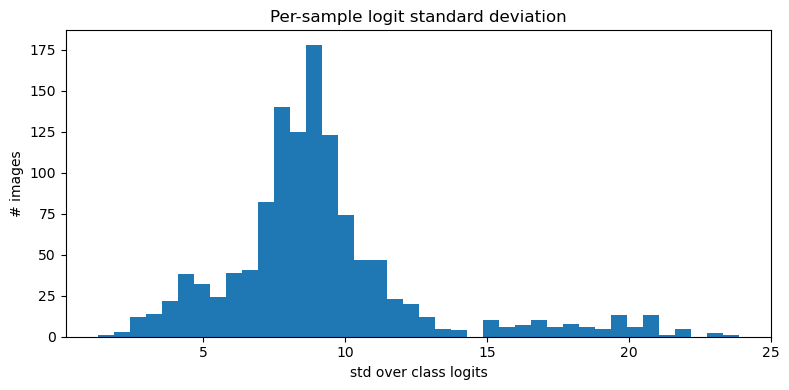

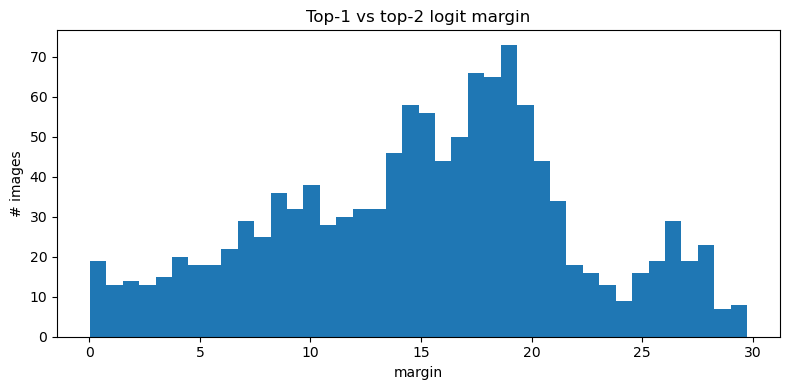

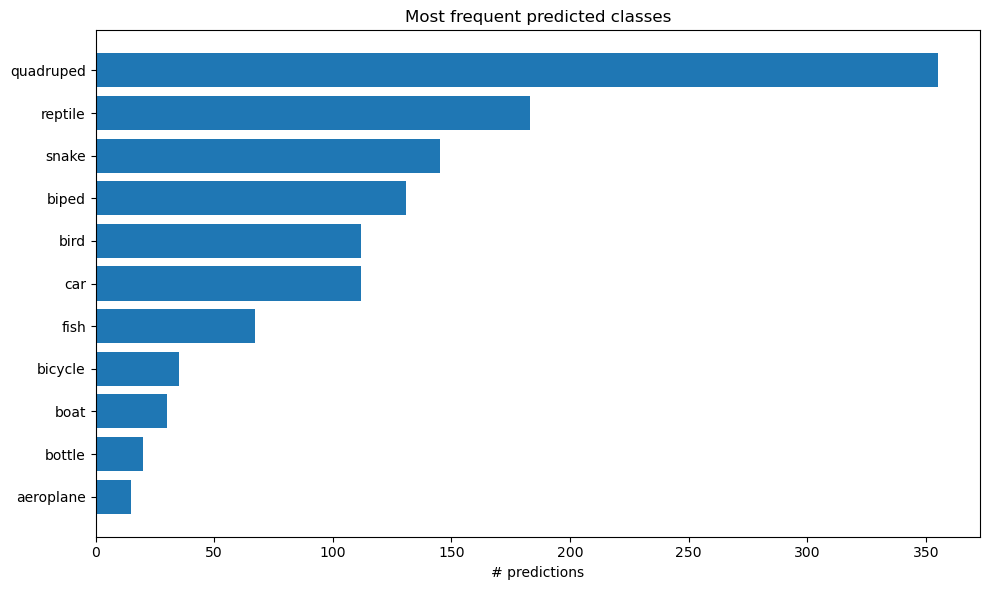

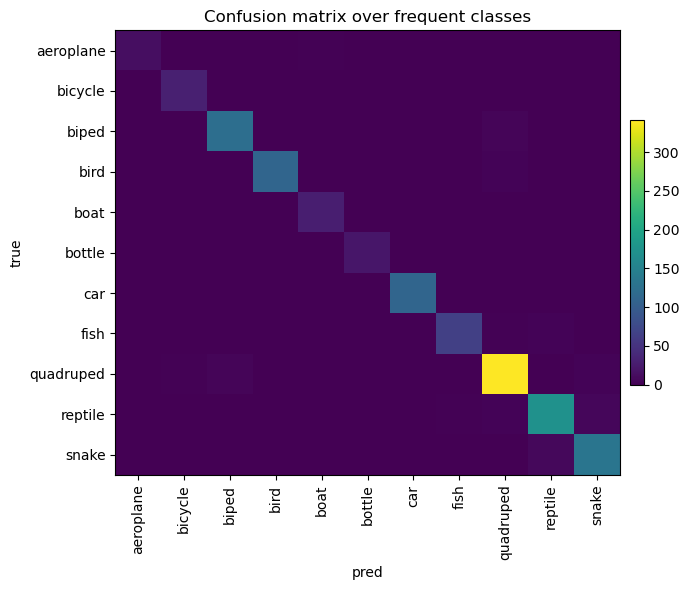

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pred_df["logit_std"].values, bins=40)
ax.set_title("Per-sample logit standard deviation")
ax.set_xlabel("std over class logits")
ax.set_ylabel("# images")
savefig(FIG_DIR / "logit_std_histogram.png", fig)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pred_df["top2_margin"].values, bins=40)
ax.set_title("Top-1 vs top-2 logit margin")
ax.set_xlabel("margin")
ax.set_ylabel("# images")
savefig(FIG_DIR / "top2_margin_histogram.png", fig)
plt.show()

pred_counts = pred_df["pred_name"].value_counts().head(30).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(pred_counts.index, pred_counts.values)
ax.set_title("Most frequent predicted classes")
ax.set_xlabel("# predictions")
savefig(FIG_DIR / "prediction_distribution_top30.png", fig)
plt.show()

# Confusion matrix over most common true/pred classes.
classes = sorted(set(pred_df["true"].value_counts().head(20).index.tolist()) | set(pred_df["pred"].value_counts().head(20).index.tolist()))
cm = np.zeros((len(classes), len(classes)), dtype=int)
pos = {c:i for i,c in enumerate(classes)}
for _, r in pred_df.iterrows():
    if int(r.true) in pos and int(r.pred) in pos:
        cm[pos[int(r.true)], pos[int(r.pred)]] += 1
fig, ax = plt.subplots(figsize=(max(7, len(classes)*0.35), max(6, len(classes)*0.35)))
im = ax.imshow(cm, aspect="auto")
ax.set_title("Confusion matrix over frequent classes")
ax.set_xlabel("pred")
ax.set_ylabel("true")
ax.set_xticks(range(len(classes)))
ax.set_xticklabels([grammar.class_names[c] for c in classes], rotation=90)
ax.set_yticks(range(len(classes)))
ax.set_yticklabels([grammar.class_names[c] for c in classes])
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
savefig(FIG_DIR / "confusion_frequent_classes.png", fig)
plt.show()


## 6. Node / edge / template decomposition

This directly inspects intermediate scores before class aggregation. It uses the parser internals to separate node singleton evidence and horizontal relation evidence. The goal is to detect whether all template scores are flat, whether edge terms dominate, or whether missing-slot penalties are overwhelming.


In [10]:
@torch.no_grad()
def decompose_batch(batch, enable_edges=ENABLE_EDGES):
    parser.eval()
    device_batch = {k: v.to(DEVICE) if torch.is_tensor(v) else v for k, v in batch.items()}
    C = parser.num_classes
    chunk = int(parser.cfg.class_chunk or C)
    node_chunks, edge_chunks, template_chunks, best_chunks = [], [], [], []
    for c0 in range(0, C, chunk):
        c1 = min(C, c0 + chunk)
        compat, mask, slot_ok = parser._node_compatibility(device_batch, c0, c1)
        node, assign = parser._node_scores(compat, mask, slot_ok, c0, c1)
        edge = parser._edge_scores(device_batch, assign, c0, c1) if enable_edges else torch.zeros_like(node)
        template = node + parser.cfg.relation_weight * edge
        _, best = parser._aggregate_templates(template, c0, c1)
        node_chunks.append(node.detach().cpu())
        edge_chunks.append(edge.detach().cpu())
        template_chunks.append(template.detach().cpu())
        best_chunks.append(best.detach().cpu())
    return {
        "node_scores": torch.cat(node_chunks, dim=1),        # [B,C,A]
        "edge_scores": torch.cat(edge_chunks, dim=1),        # [B,C,A]
        "template_scores": torch.cat(template_chunks, dim=1),# [B,C,A]
        "best_template": torch.cat(best_chunks, dim=1),      # [B,C]
    }

# Collect decomposition for first few batches.
decomp_rows = []
idx0 = 0
for bi, batch in enumerate(loader):
    if bi >= min(MAX_EVAL_BATCHES or 999999, 10):
        break
    dec = decompose_batch(batch)
    out = parser(batch, enable_edges=ENABLE_EDGES, return_parse=False)
    logits = out["logits"].detach().cpu()
    pred = logits.argmax(-1)
    labels = batch["obj_label"]
    for b in range(labels.shape[0]):
        y = int(labels[b].item())
        p = int(pred[b].item())
        ap = int(dec["best_template"][b, p].item())
        ay = int(dec["best_template"][b, y].item())
        decomp_rows.append({
            "index": idx0 + b,
            "true": y,
            "true_name": grammar.class_names[y],
            "pred": p,
            "pred_name": grammar.class_names[p],
            "correct": int(p == y),
            "pred_template": ap,
            "true_template": ay,
            "pred_node_score": float(dec["node_scores"][b, p, ap].item()),
            "pred_edge_score_raw": float(dec["edge_scores"][b, p, ap].item()),
            "pred_edge_score_weighted": float(parser.cfg.relation_weight * dec["edge_scores"][b, p, ap].item()),
            "pred_template_score": float(dec["template_scores"][b, p, ap].item()),
            "true_node_score": float(dec["node_scores"][b, y, ay].item()),
            "true_edge_score_raw": float(dec["edge_scores"][b, y, ay].item()),
            "true_edge_score_weighted": float(parser.cfg.relation_weight * dec["edge_scores"][b, y, ay].item()),
            "true_template_score": float(dec["template_scores"][b, y, ay].item()),
            "logit_true": float(logits[b, y].item()),
            "logit_pred": float(logits[b, p].item()),
        })
    idx0 += labels.shape[0]

decomp_df = pd.DataFrame(decomp_rows)
save_table(decomp_df, TAB_DIR / "parser_score_decomposition.csv")
decomp_df.head(10)


,index,true,true_name,pred,pred_name,correct,pred_template,true_template,pred_node_score,pred_edge_score_raw,pred_edge_score_weighted,pred_template_score,true_node_score,true_edge_score_raw,true_edge_score_weighted,true_template_score,logit_true,logit_pred
0,0,6,car,6,car,1,0,0,11.733194,3.099114,1.084690,12.817884,11.733194,3.099114,1.084690,12.817884,22.346939,22.346939
1,1,6,car,6,car,1,0,0,11.945482,3.117843,1.091245,13.036727,11.945482,3.117843,1.091245,13.036727,22.839560,22.839560
2,2,6,car,6,car,1,0,0,12.177593,3.087044,1.080465,13.258059,12.177593,3.087044,1.080465,13.258059,23.337688,23.337688
3,3,6,car,6,car,1,0,0,12.044416,3.418283,1.196399,13.240816,12.044416,3.418283,1.196399,13.240816,23.298687,23.298687
4,4,6,car,6,car,1,0,0,10.822301,3.089409,1.081293,11.903594,10.822301,3.089409,1.081293,11.903594,20.290255,20.290255
5,5,6,car,6,car,1,0,0,12.384167,3.379252,1.182738,13.566905,12.384167,3.379252,1.182738,13.566905,24.032619,24.032619
6,6,6,car,6,car,1,0,0,6.873735,1.237171,0.433010,7.306745,6.873735,1.237171,0.433010,7.306745,9.984209,9.984209
7,7,6,car,6,car,1,0,0,7.312885,1.559127,0.545694,7.858579,7.312885,1.559127,0.545694,7.858579,11.213891,11.213891
8,8,6,car,6,car,1,0,0,12.298904,3.484329,1.219515,13.518419,12.298904,3.484329,1.219515,13.518419,23.923399,23.923399
9,9,6,car,6,car,1,0,0,7.205359,1.144369,0.400529,7.605889,7.205359,1.144369,0.400529,7.605889,10.746423,10.746423


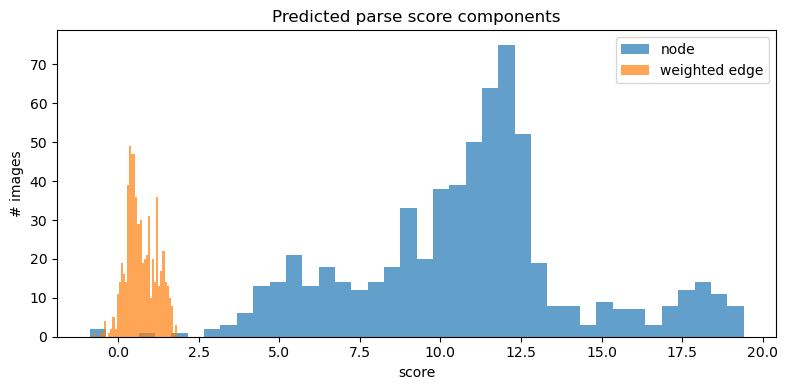

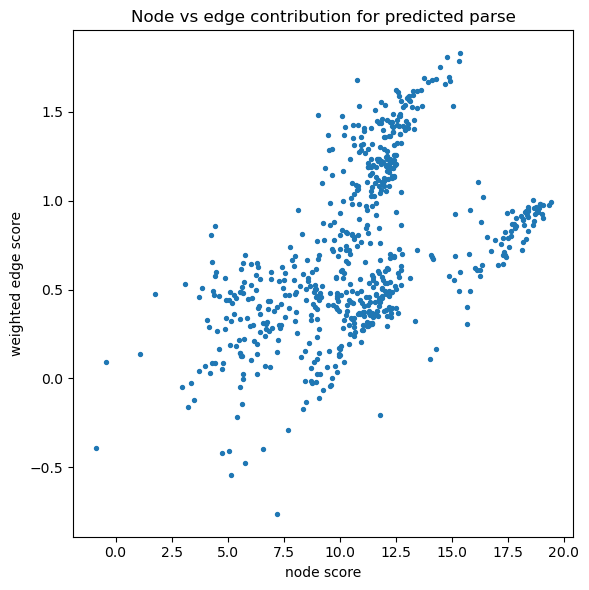

In [11]:
if len(decomp_df):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(decomp_df["pred_node_score"], bins=40, alpha=0.7, label="node")
    ax.hist(decomp_df["pred_edge_score_weighted"], bins=40, alpha=0.7, label="weighted edge")
    ax.set_title("Predicted parse score components")
    ax.set_xlabel("score")
    ax.set_ylabel("# images")
    ax.legend()
    savefig(FIG_DIR / "score_component_histogram.png", fig)
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(decomp_df["pred_node_score"], decomp_df["pred_edge_score_weighted"], s=8)
    ax.set_title("Node vs edge contribution for predicted parse")
    ax.set_xlabel("node score")
    ax.set_ylabel("weighted edge score")
    savefig(FIG_DIR / "node_vs_edge_scatter.png", fig)
    plt.show()


## 7. Optional raw image loader

The terminal cache does not store raw images. If `USE_RAW_IMAGE_DATASET=True`, this cell tries to load the PartImageNet dataset using `CONFIG_PATH`. Record order should match the cache order because the cache script uses `shuffle=False`.


In [12]:
raw_dataset = None
if USE_RAW_IMAGE_DATASET:
    try:
        from partcat_hkg.config import load_config
        from partcat_hkg.data.loaders import make_datasets
        cfg = load_config(CONFIG_PATH)
        train_ds, val_ds = make_datasets(cfg)
        for ds in (train_ds, val_ds):
            if hasattr(ds, "transform") and hasattr(ds.transform, "train"):
                ds.transform.train = False
        raw_dataset = val_ds if "val" in CACHE_PATH.name.lower() else train_ds
        print("Loaded raw dataset for overlays:", type(raw_dataset).__name__, "len=", len(raw_dataset))
    except Exception as e:
        raw_dataset = None
        print("Could not load raw image dataset; continuing with terminal-mask-only plots.")
        print(repr(e))
else:
    print("Raw image dataset disabled. Set USE_RAW_IMAGE_DATASET=True if you want image overlays.")

def image_from_dataset(index: int):
    if raw_dataset is None:
        return None
    try:
        item = raw_dataset[int(index)]
        img = item.get("image") if isinstance(item, dict) else item[0]
        if torch.is_tensor(img):
            x = img.detach().cpu().float()
            if x.ndim == 3:
                x = x.permute(1, 2, 0)
            # robust display scaling; works even for normalized tensors.
            lo, hi = torch.quantile(x.flatten(), torch.tensor([0.01, 0.99]))
            x = ((x - lo) / (hi - lo).clamp_min(1e-6)).clamp(0, 1).numpy()
            return x
    except Exception as e:
        print(f"raw image load failed for index {index}: {e}")
    return None


Raw image dataset disabled. Set USE_RAW_IMAGE_DATASET=True if you want image overlays.


## 8. Terminal and parse graph visualization helpers


In [13]:
def _part_name(k: int) -> str:
    return grammar.part_names[int(k)] if 0 <= int(k) < len(grammar.part_names) else str(int(k))

def _class_name(c: int) -> str:
    return grammar.class_names[int(c)] if 0 <= int(c) < len(grammar.class_names) else str(int(c))

def _mask_rgb(mask, color):
    h, w = mask.shape
    arr = np.zeros((h, w, 4), dtype=float)
    arr[..., :3] = color[:3]
    arr[..., 3] = mask * color[3]
    return arr

def visualize_terminals(index: int, save=True):
    r = dataset[int(index)]
    valid = r["terminal_valid"].bool()
    img = image_from_dataset(index)
    masks = r["terminal_mask"].float().numpy()
    geom = r["terminal_geom"].float().numpy()
    parts = r["terminal_part"].long().numpy()
    scores = r["terminal_score"].float().numpy()
    n = int(valid.sum().item())
    canvas_h = canvas_w = int(masks.shape[-1])
    if img is None:
        bg = np.ones((canvas_h, canvas_w, 3), dtype=float)
        extent = (0, canvas_w, canvas_h, 0)
    else:
        bg = img
        canvas_h, canvas_w = bg.shape[:2]
        extent = (0, canvas_w, canvas_h, 0)
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(bg)
    colors = plt.cm.tab20(np.linspace(0, 1, max(n, 1)))
    j = 0
    for i in range(len(valid)):
        if not bool(valid[i]):
            continue
        mask = masks[i]
        if img is not None and mask.shape[:2] != bg.shape[:2]:
            # nearest resize via torch to avoid cv2 dependency
            mt = torch.tensor(mask)[None, None].float()
            mask = torch.nn.functional.interpolate(mt, size=bg.shape[:2], mode="nearest")[0,0].numpy()
        ax.imshow(_mask_rgb(mask, colors[j]), interpolation="nearest")
        cx = float(geom[i, 0]) * (canvas_w - 1)
        cy = float(geom[i, 1]) * (canvas_h - 1)
        ax.scatter([cx], [cy], s=30)
        ax.text(cx, cy, f"{i}:{_part_name(parts[i])}\n{scores[i]:.2f}", fontsize=7)
        j += 1
    label = int(r["obj_label"].item())
    ax.set_title(f"Terminal proposals index={index} true={_class_name(label)} n={n}")
    ax.axis("off")
    if save:
        path = FIG_DIR / "samples" / f"terminals_{index:05d}.png"
        savefig(path, fig)
    return fig

def parse_for_indices(indices, enable_edges=ENABLE_EDGES):
    rows = [dataset[int(i)] for i in indices]
    batch = collate_strict_aog(rows)
    with torch.no_grad():
        out = parser(batch, enable_edges=enable_edges, return_parse=True)
    return batch, out

def visualize_parse(index: int, enable_edges=ENABLE_EDGES, save=True):
    batch, out = parse_for_indices([index], enable_edges=enable_edges)
    pg = out["parse_graph"][0]
    r = dataset[int(index)]
    img = image_from_dataset(index)
    masks = r["terminal_mask"].float().numpy()
    geom = r["terminal_geom"].float().numpy()
    if img is None:
        canvas_h = canvas_w = int(masks.shape[-1])
        bg = np.ones((canvas_h, canvas_w, 3), dtype=float)
    else:
        bg = img
        canvas_h, canvas_w = bg.shape[:2]
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(bg)
    assigned = [s for s in pg["slots"] if "terminal" in s]
    colors = plt.cm.tab20(np.linspace(0, 1, max(len(assigned), 1)))
    terminal_to_slot = {}
    for j, srow in enumerate(assigned):
        t = int(srow["terminal"])
        terminal_to_slot[int(srow["slot"])] = t
        mask = masks[t]
        if mask.shape[:2] != bg.shape[:2]:
            mt = torch.tensor(mask)[None, None].float()
            mask = torch.nn.functional.interpolate(mt, size=bg.shape[:2], mode="nearest")[0,0].numpy()
        ax.imshow(_mask_rgb(mask, colors[j]), interpolation="nearest")
        cx = float(geom[t, 0]) * (canvas_w - 1)
        cy = float(geom[t, 1]) * (canvas_h - 1)
        ax.scatter([cx], [cy], s=45)
        ax.text(cx, cy, f"slot{srow['slot']} {_part_name(batch['terminal_part'][0,t].item())}\nt{t} {float(batch['terminal_score'][0,t]):.2f}", fontsize=7)
    # Edges among assigned slots.
    for erow in pg.get("edges", []):
        si, sj = int(erow["slot_i"]), int(erow["slot_j"])
        if si in terminal_to_slot and sj in terminal_to_slot:
            ti, tj = terminal_to_slot[si], terminal_to_slot[sj]
            xi, yi = float(geom[ti,0])*(canvas_w-1), float(geom[ti,1])*(canvas_h-1)
            xj, yj = float(geom[tj,0])*(canvas_w-1), float(geom[tj,1])*(canvas_h-1)
            ax.plot([xi, xj], [yi, yj], linewidth=1.5)
            ax.text((xi+xj)/2, (yi+yj)/2, f"e {erow.get('support',0):.2f}", fontsize=6)
    true_label = int(r["obj_label"].item())
    pred_label = int(out["logits"].argmax(-1)[0].detach().cpu().item())
    ax.set_title(f"Parse index={index} true={_class_name(true_label)} pred={_class_name(pred_label)} template={pg['template']}")
    ax.axis("off")
    if save:
        path = FIG_DIR / "samples" / f"parse_{index:05d}.png"
        savefig(path, fig)
    return fig, pg


## 9. Save sample terminal and parse visualizations

The notebook saves a mix of correct, wrong, high-margin, and random samples. If the model is collapsed, these plots are useful for checking whether the terminal evidence or the grammar is the source of collapse.


In [14]:
indices = []
if len(pred_df):
    wrong = pred_df[pred_df.correct == 0].sort_values("top2_margin", ascending=False)["index"].head(NUM_VIS_SAMPLES // 2).tolist()
    correct = pred_df[pred_df.correct == 1].sort_values("top2_margin", ascending=False)["index"].head(NUM_VIS_SAMPLES // 4).tolist()
    random_pool = pred_df.sample(min(NUM_VIS_SAMPLES, len(pred_df)), random_state=RANDOM_SEED)["index"].tolist()
    indices = []
    for i in wrong + correct + random_pool:
        if int(i) not in indices:
            indices.append(int(i))
        if len(indices) >= NUM_VIS_SAMPLES:
            break
else:
    indices = list(range(min(NUM_VIS_SAMPLES, len(dataset))))

vis_records = []
for idx in indices:
    try:
        fig = visualize_terminals(idx, save=True)
        plt.close(fig)
        fig, pg = visualize_parse(idx, save=True)
        plt.close(fig)
        vis_records.append({"index": idx, "pred_class": pg.get("class"), "template": pg.get("template"), "n_slots": len(pg.get("slots", [])), "n_edges": len(pg.get("edges", []))})
    except Exception as e:
        vis_records.append({"index": idx, "error": repr(e)})
        print("visualization failed", idx, repr(e))
vis_df = pd.DataFrame(vis_records)
save_table(vis_df, TAB_DIR / "visualized_samples.csv")
vis_df


,index,pred_class,template,n_slots,n_edges
0,1050,biped,1,12,12
1,903,biped,1,12,12
2,515,quadruped,1,8,10
3,253,reptile,0,8,12
4,1007,biped,1,12,12
5,569,biped,1,12,12
6,182,biped,1,12,12
7,139,biped,1,12,12
8,195,biped,1,12,12
9,310,snake,1,8,12


## 10. Relation residual diagnostics for predicted parse graphs

For each predicted parse graph, this compares the observed terminal-terminal relation vector with the selected grammar edge template. Large residuals indicate that the selected template relation is not explaining the observed part layout.


In [15]:
def relation_residuals_for_index(index: int):
    batch, out = parse_for_indices([index], enable_edges=ENABLE_EDGES)
    pg = out["parse_graph"][0]
    pred = int(out["logits"].argmax(-1)[0].detach().cpu().item())
    a = int(pg["template"])
    r = dataset[int(index)]
    rel_pair = terminal_pair_relations(r["terminal_geom"].unsqueeze(0))[0]  # [N,N,R]
    slot_to_terminal = {int(s["slot"]): int(s["terminal"]) for s in pg["slots"] if "terminal" in s}
    rows = []
    edge_ids = [e for e, row in enumerate(grammar.edges.tolist()) if int(row[0]) == pred and int(row[1]) == a]
    for e in edge_ids:
        c, aa, si, sj = map(int, grammar.edges[e].tolist())
        if si not in slot_to_terminal or sj not in slot_to_terminal:
            rows.append({"index": index, "edge_id": e, "slot_i": si, "slot_j": sj, "status": "missing_endpoint"})
            continue
        ti, tj = slot_to_terminal[si], slot_to_terminal[sj]
        obs = rel_pair[ti, tj]
        mu = grammar.edge_rel_mean[e]
        var = grammar.edge_rel_var[e].clamp_min(1e-4)
        z = (obs - mu) / torch.sqrt(var)
        row = {
            "index": index,
            "pred_class": pred,
            "pred_name": _class_name(pred),
            "template": a,
            "edge_id": e,
            "slot_i": si,
            "slot_j": sj,
            "terminal_i": ti,
            "terminal_j": tj,
            "part_i": _part_name(int(grammar.slot_part[c, a, si].item())),
            "part_j": _part_name(int(grammar.slot_part[c, a, sj].item())),
            "support": float(grammar.edge_support[e].item()),
            "status": "ok",
            "mahalanobis_mean_abs_z": float(z.abs().mean().item()),
            "relation_ll": float((-0.5 * (((obs - mu) ** 2) / var + var.log()).mean()).item()),
        }
        for j, name in enumerate(REL_FEATURE_NAMES):
            row[f"obs_{name}"] = float(obs[j].item())
            row[f"mu_{name}"] = float(mu[j].item())
            row[f"z_{name}"] = float(z[j].item())
        rows.append(row)
    return rows

res_rows = []
for idx in indices:
    try:
        res_rows.extend(relation_residuals_for_index(idx))
    except Exception as e:
        res_rows.append({"index": idx, "status": "error", "error": repr(e)})
rel_res_df = pd.DataFrame(res_rows)
save_table(rel_res_df, TAB_DIR / "relation_residuals_visualized_samples.csv")
rel_res_df.head(20)


,index,pred_class,pred_name,template,edge_id,slot_i,slot_j,terminal_i,terminal_j,part_i,part_j,support,status,mahalanobis_mean_abs_z,relation_ll,obs_dx,mu_dx,z_dx,obs_dy,mu_dy,z_dy,obs_dist,mu_dist,z_dist,obs_area_i,mu_area_i,z_area_i,obs_area_j,mu_area_j,z_area_j,obs_log_area_ratio,mu_log_area_ratio,z_log_area_ratio,obs_w_i,mu_w_i,z_w_i,obs_h_i,mu_h_i,z_h_i,obs_w_j,mu_w_j,z_w_j,obs_h_j,mu_h_j,z_h_j
0,1050,2.0,biped,1.0,41,0,1,0.0,0.0,body,body,1.000000,ok,1.138978,0.472546,0.000000,0.167156,-1.228359,0.000000,0.003995,-0.012971,0.000100,0.338760,-2.076209,0.232393,0.068746,1.537492,0.232393,0.075848,1.437239,0.000000,-0.284885,0.058307,0.615625,0.229004,1.534486,0.559375,0.253266,1.098283,0.615625,0.250588,1.408747,0.559375,0.276193,0.997690
1,1050,2.0,biped,1.0,42,0,8,0.0,2.0,body,hand,0.986880,ok,0.714430,1.026505,-0.017108,0.010452,-0.162522,0.291217,0.003796,1.121982,0.291719,0.257886,0.202202,0.232393,0.069471,1.523697,0.058047,0.063673,-0.086254,1.387177,-1.361482,0.757518,0.615625,0.230516,1.522201,0.559375,0.255078,1.087324,0.231250,0.284601,-0.248428,0.434375,0.334652,0.432172
2,1050,2.0,biped,1.0,43,0,4,0.0,3.0,body,foot,0.981050,ok,0.723888,1.111222,0.158279,0.046550,0.614224,0.231865,0.151517,0.327123,0.280737,0.288878,-0.043459,0.232393,0.069940,1.516829,0.037266,0.039649,-0.051975,1.830357,-0.657694,0.715783,0.615625,0.231691,1.515462,0.559375,0.256213,1.081747,0.343750,0.234798,0.544698,0.334375,0.208024,0.827579
3,1050,2.0,biped,1.0,44,0,9,0.0,2.0,body,hand,0.714286,ok,0.742303,1.009639,-0.017108,0.175627,-0.917046,0.291217,0.008273,0.991521,0.291719,0.342855,-0.259048,0.232393,0.078979,1.379940,0.058047,0.044458,0.236314,1.387177,-0.283686,0.457010,0.615625,0.255325,1.382519,0.559375,0.286218,0.946846,0.231250,0.222640,0.040653,0.434375,0.258253,0.812138
4,1050,2.0,biped,1.0,45,8,9,2.0,2.0,hand,hand,0.714286,ok,0.576085,1.173052,0.000000,0.206188,-1.449256,0.000000,0.010015,-0.037297,0.000100,0.335864,-2.255973,0.058047,0.047478,0.190156,0.058047,0.044458,0.236314,0.000000,0.292812,-0.086018,0.231250,0.227003,0.022538,0.434375,0.288712,0.630507,0.231250,0.222640,0.040653,0.434375,0.258253,0.812138
5,1050,2.0,biped,1.0,46,0,5,0.0,3.0,body,foot,0.584548,ok,0.795176,1.077101,0.158279,0.176248,-0.089456,0.231865,0.137749,0.376051,0.280737,0.340233,-0.308188,0.232393,0.067155,1.583481,0.037266,0.025337,0.315535,1.830357,0.005730,0.511401,0.615625,0.229465,1.531071,0.559375,0.250647,1.122892,0.343750,0.171859,1.047638,0.334375,0.170472,1.066047
6,1050,2.0,biped,1.0,47,4,5,3.0,3.0,foot,foot,0.584548,ok,0.847529,1.331008,0.000000,0.183275,-1.293381,0.000000,0.001297,-0.007318,0.000100,0.257600,-1.882402,0.037266,0.023007,0.412029,0.037266,0.025337,0.315535,0.000000,-0.104936,0.032847,0.343750,0.160653,1.140687,0.334375,0.157341,1.277408,0.343750,0.171859,1.047638,0.334375,0.170472,1.066047
7,1050,2.0,biped,1.0,48,0,2,0.0,0.0,body,body,0.530612,ok,1.303249,0.224563,0.000000,0.280485,-1.663949,0.000000,0.013741,-0.043210,0.000100,0.415151,-2.186023,0.232393,0.065192,1.525735,0.232393,0.055478,1.813791,0.000000,0.210572,-0.047017,0.615625,0.219797,1.589196,0.559375,0.236195,1.178528,0.615625,0.203237,1.674754,0.559375,0.214981,1.310286
8,1050,2.0,biped,1.0,49,1,2,0.0,0.0,body,body,0.530612,ok,1.280518,0.346381,0.000000,0.128117,-1.145969,0.000000,0.027213,-0.085297,0.000100,0.311348,-1.675709,0.232393,0.050738,1.910982,0.232393,0.055478,1.813791,0.000000,-0.175226,0.040837,0.615625,0.194557,1.724289,0.559375,0.198206,1.423269,0.615625,0.203237,1.674754,0.559375,0.214981,1.310286
9,1050,2.0,biped,1.0,50,0,10,0.0,2.0,body,hand,0.411079,ok,0.879677,0.979697,-0.017108,0.271288,-1.478630,0.291217,-0.001234,0.989732,0.291719,0.400545,-0.554524,0.232393,0.083964,1.291261,0.058047,0.033720,0.523713,1.387177,0.018451,0.405771,0.615625,0.269315,1.312837,0.559375,0.297883,0.896529,0.231250,0.188763,0.250732,0.434375,0.222462,1.093039


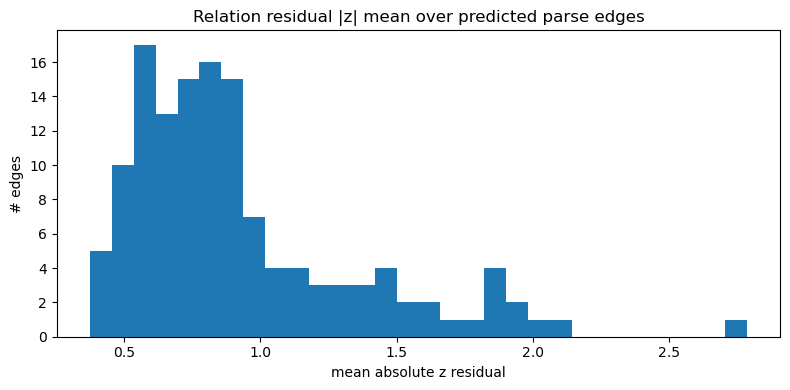

,index,pred_class,pred_name,template,edge_id,slot_i,slot_j,terminal_i,terminal_j,part_i,part_j,support,status,mahalanobis_mean_abs_z,relation_ll,obs_dx,mu_dx,z_dx,obs_dy,mu_dy,z_dy,obs_dist,mu_dist,z_dist,obs_area_i,mu_area_i,z_area_i,obs_area_j,mu_area_j,z_area_j,obs_log_area_ratio,mu_log_area_ratio,z_log_area_ratio,obs_w_i,mu_w_i,z_w_i,obs_h_i,mu_h_i,z_h_i,obs_w_j,mu_w_j,z_w_j,obs_h_j,mu_h_j,z_h_j
134,1156,8.0,quadruped,1.0,228,9,10,0.0,0.0,head,head,0.162175,ok,2.785260,-4.289743,0.000000,0.244480,-1.349039,0.000000,-0.020102,0.083012,0.000100,0.348598,-2.007593,0.393066,0.033890,6.162761,0.393066,0.038569,5.740001,0.000000,-0.121462,0.029793,0.550000,0.156939,2.573261,0.953125,0.199221,3.898824,0.550000,0.173791,2.233708,0.953125,0.208157,3.774604
112,310,10.0,snake,1.0,65,0,3,0.0,0.0,body,body,0.205463,ok,2.128079,-1.716091,0.000000,0.511246,-2.613194,0.000000,0.018997,-0.060795,0.000100,0.599488,-3.064158,0.458076,0.052097,3.737979,0.458076,0.058684,3.246638,0.000000,0.020326,-0.005600,0.890625,0.214595,2.848162,0.640625,0.231846,1.562858,0.890625,0.229751,2.479434,0.640625,0.224350,1.661977
113,310,10.0,snake,1.0,66,1,3,0.0,0.0,body,body,0.205463,ok,2.018800,-1.358177,0.000000,0.334826,-1.843732,0.000000,0.012328,-0.040051,0.000100,0.449434,-2.305176,0.458076,0.044356,3.557321,0.458076,0.058684,3.246638,0.000000,-0.640900,0.171025,0.890625,0.180546,2.884607,0.640625,0.169870,1.998038,0.890625,0.229751,2.479434,0.640625,0.224350,1.661977
135,1156,8.0,quadruped,1.0,229,1,9,1.0,0.0,body,head,0.131970,ok,1.968538,-1.117090,0.153708,-0.147286,1.043878,0.187097,-0.084533,1.112449,0.242139,0.371081,-0.700316,0.359199,0.071635,2.865591,0.393066,0.089084,3.815036,-0.090101,-1.770985,0.495149,1.000000,0.262720,2.703383,0.734375,0.231052,2.190431,0.550000,0.299505,1.506410,0.953125,0.362027,3.252733
114,310,10.0,snake,1.0,67,2,3,0.0,0.0,body,body,0.205463,ok,1.952837,-1.333635,0.000000,0.168446,-1.286254,0.000000,0.013312,-0.043651,0.000100,0.328940,-1.882854,0.458076,0.044935,4.329053,0.458076,0.058684,3.246638,0.000000,-0.169428,0.045848,0.890625,0.221857,2.608695,0.640625,0.199115,1.943962,0.890625,0.229751,2.479434,0.640625,0.224350,1.661977
110,310,10.0,snake,1.0,63,0,2,0.0,0.0,body,body,0.414489,ok,1.891621,-1.127325,0.000000,0.368049,-1.982612,0.000000,0.012495,-0.039642,0.000100,0.484713,-2.609876,0.458076,0.065810,3.202101,0.458076,0.061283,3.367748,0.000000,0.298641,-0.073204,0.890625,0.253689,2.377269,0.640625,0.264264,1.365872,0.890625,0.245156,2.303697,0.640625,0.226880,1.594189
136,1156,8.0,quadruped,1.0,230,0,1,1.0,1.0,body,body,0.131970,ok,1.888582,-0.917098,0.000000,0.250320,-1.710400,0.000000,-0.029407,0.104118,0.000100,0.385068,-3.002404,0.359199,0.102078,2.317506,0.359199,0.071635,2.865591,0.000000,0.868398,-0.166740,1.000000,0.349494,2.263860,0.734375,0.325352,1.561383,1.000000,0.262720,2.703383,0.734375,0.231052,2.190431
130,1156,8.0,quadruped,1.0,224,0,9,1.0,0.0,body,head,0.998606,ok,1.852470,-0.715303,0.153708,-0.019165,0.722210,0.187097,-0.108668,1.750415,0.242139,0.290778,-0.419075,0.359199,0.156498,2.061965,0.393066,0.082761,3.997295,-0.090101,0.829964,-0.512713,1.000000,0.512925,2.437929,0.734375,0.443968,1.539991,0.550000,0.297303,1.570396,0.953125,0.358599,3.512707
111,310,10.0,snake,1.0,64,1,2,0.0,0.0,body,body,0.414489,ok,1.821380,-0.979176,0.000000,0.175484,-1.206714,0.000000,-0.000533,0.001831,0.000100,0.320845,-1.745660,0.458076,0.050708,3.493106,0.458076,0.061283,3.367748,0.000000,-0.526265,0.132477,0.890625,0.202830,2.574504,0.640625,0.190383,1.793874,0.890625,0.245156,2.303697,0.640625,0.226880,1.594189
117,310,10.0,snake,1.0,70,6,7,1.0,2.0,head,head,0.195962,ok,1.815599,-0.390398,-0.103251,0.165859,-2.176923,0.158369,-0.035366,0.769289,0.189055,0.291504,-0.683163,0.125889,0.011691,3.611253,0.000225,0.017041,-0.399629,6.328791,-0.246418,2.537148,0.550000,0.117765,3.798084,0.337500,0.110701,2.441822,0.025000,0.129375,-0.845543,0.018750,0.129697,-0.893139


In [16]:
if len(rel_res_df) and "mahalanobis_mean_abs_z" in rel_res_df.columns:
    ok = rel_res_df[rel_res_df.status == "ok"].copy()
    if len(ok):
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(ok["mahalanobis_mean_abs_z"], bins=30)
        ax.set_title("Relation residual |z| mean over predicted parse edges")
        ax.set_xlabel("mean absolute z residual")
        ax.set_ylabel("# edges")
        savefig(FIG_DIR / "relation_residual_histogram.png", fig)
        plt.show()
        display(ok.sort_values("mahalanobis_mean_abs_z", ascending=False).head(20))
    else:
        print("No relation residual rows with status=ok.")
else:
    print("No relation residual diagnostics available.")


## 11. Template usage diagnostics

This checks whether the parser is actually using multiple Or branches. A strict AOG should preserve alternative configurations; if one branch dominates all images/classes, the grammar or scoring may be too flat.


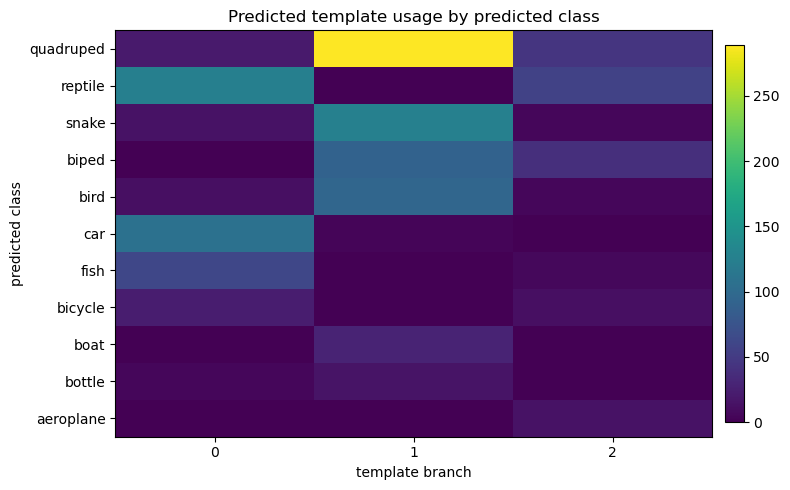

,pred,pred_name,pred_template,count
19,8,quadruped,1,289
25,10,snake,1,126
21,9,reptile,0,125
14,6,car,0,108
8,3,bird,1,95
5,2,biped,1,91
16,7,fish,0,61
23,9,reptile,2,57
20,8,quadruped,2,45
6,2,biped,2,39


In [17]:
usage_rows = []
for bi, batch in enumerate(loader):
    if MAX_EVAL_BATCHES and bi >= MAX_EVAL_BATCHES:
        break
    with torch.no_grad():
        out = parser(batch, enable_edges=ENABLE_EDGES, return_parse=False)
    pred = out["logits"].argmax(-1).detach().cpu()
    best = out["best_template"].detach().cpu()
    labels = batch["obj_label"]
    for b in range(pred.shape[0]):
        p = int(pred[b].item())
        y = int(labels[b].item())
        usage_rows.append({
            "true": y,
            "true_name": _class_name(y),
            "pred": p,
            "pred_name": _class_name(p),
            "pred_template": int(best[b, p].item()),
            "true_template": int(best[b, y].item()),
        })
usage_df = pd.DataFrame(usage_rows)
save_table(usage_df, TAB_DIR / "template_usage_per_sample.csv")

pred_usage = usage_df.groupby(["pred", "pred_name", "pred_template"]).size().reset_index(name="count").sort_values("count", ascending=False)
save_table(pred_usage, TAB_DIR / "template_usage_predicted.csv")

# Heatmap for top predicted classes.
top_pred_classes = usage_df["pred"].value_counts().head(min(40, grammar.num_classes)).index.tolist()
heat = np.zeros((len(top_pred_classes), grammar.num_templates), dtype=int)
for i, c in enumerate(top_pred_classes):
    sub = usage_df[usage_df.pred == c]
    for a, cnt in sub["pred_template"].value_counts().items():
        if 0 <= int(a) < grammar.num_templates:
            heat[i, int(a)] = int(cnt)
fig, ax = plt.subplots(figsize=(8, max(5, len(top_pred_classes)*0.22)))
im = ax.imshow(heat, aspect="auto")
ax.set_title("Predicted template usage by predicted class")
ax.set_xlabel("template branch")
ax.set_ylabel("predicted class")
ax.set_xticks(range(grammar.num_templates))
ax.set_yticks(range(len(top_pred_classes)))
ax.set_yticklabels([_class_name(c) for c in top_pred_classes])
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
savefig(FIG_DIR / "template_usage_heatmap.png", fig)
plt.show()

pred_usage.head(20)


## 12. Final diagnostic report

This writes a markdown report and manifest. Check the warning list first if performance is flat or at chance.


In [18]:
warnings = []
if eval_summary.get("uniform_warning"):
    warnings.append("Parser logits look uniform or predictions collapsed to very few classes.")
if int((terminal_df.n_terminals == 0).sum()) > 0:
    warnings.append(f"{int((terminal_df.n_terminals == 0).sum())} images have zero terminals.")
if int((~terminal_df.all_finite).sum()) > 0:
    warnings.append("Some terminal tensors contain non-finite values.")
if int((terminal_df.bad_part_ids > 0).sum()) > 0:
    warnings.append("Some terminal records contain invalid part ids.")
if int(grammar.template_valid.sum().item()) == 0:
    warnings.append("Grammar has no valid templates.")
if int(grammar.slot_valid.sum().item()) == 0:
    warnings.append("Grammar has no valid slots.")
if int(grammar.edges.shape[0]) == 0:
    warnings.append("Grammar has no horizontal relation edges; parse graphs are node-only.")
if len(class_df) and float(class_df.zero_terminal_images.sum()) / max(float(class_df.n_images.sum()), 1.0) > 0.05:
    warnings.append("More than 5% of images have zero terminals; Stage-1 threshold may be too strict.")

report = []
report.append("# Strict AOG diagnostic report\n")
report.append(f"- grammar: `{GRAMMAR_PATH}`")
report.append(f"- cache: `{CACHE_PATH}`")
report.append(f"- checkpoint: `{CKPT_PATH if ckpt_loaded else 'not loaded'}`")
report.append(f"- evaluated samples: {eval_summary.get('n_eval', 0)}")
report.append(f"- accuracy: {eval_summary.get('accuracy', 0):.4f}")
report.append(f"- mean logit std: {eval_summary.get('mean_logit_std', 0):.6f}")
report.append(f"- predicted unique classes: {eval_summary.get('pred_unique_classes', 0)}")
report.append(f"- terminal count mean: {terminal_df.n_terminals.mean():.2f}")
report.append(f"- zero-terminal images: {int((terminal_df.n_terminals == 0).sum())}")
report.append(f"- valid templates: {int(grammar.template_valid.sum().item())}")
report.append(f"- valid slots: {int(grammar.slot_valid.sum().item())}")
report.append(f"- horizontal relation edges: {int(grammar.edges.shape[0])}")
report.append("\n## Warnings\n")
if warnings:
    for w in warnings:
        report.append(f"- {w}")
else:
    report.append("- none")
report.append("\n## Recommended next checks\n")
report.append("- If logits are uniform: inspect `terminal_count_histogram.png`, `template_prior_heatmap.png`, and `parser_score_decomposition.csv`.")
report.append("- If terminals are sparse: lower terminal extraction threshold or inspect Stage-1 part diagnostics.")
report.append("- If relation residuals are large: rebuild grammar from better terminal masks or reduce edge weight.")
report.append("- If template usage collapses: reduce template count or revisit template clustering/support thresholds.")

report_path = REPORT_DIR / "diagnostic_report.md"
report_path.write_text("\n".join(report), encoding="utf-8")
manifest_df = pd.DataFrame(manifest)
save_table(manifest_df, OUT_DIR / "diagnostics_manifest.csv")
save_json({"warnings": warnings, "eval_summary": eval_summary}, REPORT_DIR / "final_diagnostic_summary.json")
print(report_path)
print("\n".join(report[:40]))


/home/dfli/instance_slot_aog/runs/strict_aog_diagnostics/reports/diagnostic_report.md
# Strict AOG diagnostic report

- grammar: `/home/dfli/instance_slot_aog/runs/strict_aog_cache/strict_aog.pt`
- cache: `/home/dfli/instance_slot_aog/runs/strict_aog_cache/val_strict_aog_terminals.pt`
- checkpoint: `/home/dfli/instance_slot_aog/runs/strict_aog/checkpoints/strict_aog_best.pt`
- evaluated samples: 1205
- accuracy: 0.9510
- mean logit std: 9.134872
- predicted unique classes: 11
- terminal count mean: 5.25
- zero-terminal images: 0
- valid templates: 33
- valid slots: 241
- horizontal relation edges: 287

## Warnings

- none

## Recommended next checks

- If logits are uniform: inspect `terminal_count_histogram.png`, `template_prior_heatmap.png`, and `parser_score_decomposition.csv`.
- If terminals are sparse: lower terminal extraction threshold or inspect Stage-1 part diagnostics.
- If relation residuals are large: rebuild grammar from better terminal masks or reduce edge weight.
- If te

## 13. Archive diagnostics directory

Run this after all cells to create a local zip you can share or compare across runs.


In [19]:
import shutil
zip_base = OUT_DIR.parent / (OUT_DIR.name + "_bundle")
zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=OUT_DIR)
print("Saved diagnostics bundle:", zip_path)


Saved diagnostics bundle: /home/dfli/instance_slot_aog/runs/strict_aog_diagnostics_bundle.zip
